Just for sanity check of the integrity of data provided by `EquityCalculator.exe`

In [57]:
# Read the equity matrix from the binary file and reshape it into a 169x169 matrix
import numpy as np
file_path: str = r".\equity_169x169_matrix.bin"
equity_matrix: np.ndarray = np.fromfile(file_path, dtype=np.float32)
equity_matrix = equity_matrix.reshape((169, 169))
np.set_printoptions(precision=4, suppress=True, linewidth=150)

sanity_check_matrix = equity_matrix[:10, :10]

print("=== Sanity Check: Top-left 10x10 Equity Matrix ===")
print(sanity_check_matrix)

=== Sanity Check: Top-left 10x10 Equity Matrix ===
[[0.5    0.8784 0.8747 0.8704 0.8668 0.8844 0.8804 0.8806 0.8821 0.8673]
 [0.1216 0.5    0.7125 0.7105 0.7073 0.7117 0.7098 0.7068 0.7091 0.6978]
 [0.1253 0.2875 0.5    0.708  0.7053 0.7066 0.7042 0.7052 0.7045 0.6936]
 [0.1296 0.2895 0.292  0.5    0.6989 0.7005 0.698  0.6963 0.6991 0.6844]
 [0.1332 0.2927 0.2947 0.3011 0.5    0.6913 0.6893 0.6863 0.6869 0.6761]
 [0.1156 0.2883 0.2934 0.2995 0.3087 0.5    0.6667 0.665  0.6644 0.6509]
 [0.1196 0.2902 0.2958 0.302  0.3107 0.3333 0.5    0.6443 0.6444 0.63  ]
 [0.1194 0.2932 0.2948 0.3037 0.3137 0.335  0.3557 0.5    0.6149 0.602 ]
 [0.1179 0.2909 0.2955 0.3009 0.3131 0.3356 0.3556 0.3851 0.5    0.567 ]
 [0.1327 0.3022 0.3064 0.3156 0.3239 0.3491 0.37   0.398  0.433  0.5   ]]


In [58]:
# specific hand equity checks
rank: dict[str, int] = {'A':0, 'K':1, 'Q':2, 'J':3, 'T':4, '9':5, '8':6, '7':7, '6':8, '5':9, '4':10, '3':11, '2':12}

hero_hand: str = "AKs"
villain_hand: str = "AXs"

def hand_to_index(hand: str) -> int:
    rank1, rank2 = hand[0], hand[1]
    idx1, idx2 = rank[rank1], rank[rank2]
    if idx1 == idx2:
        return idx1 * 13 + idx2
    elif hand[2] == 's':
        return min(idx1, idx2) * 13 + max(idx1, idx2)
    else:
        return max(idx1, idx2) * 13 + min(idx1, idx2)
hero_idx: int = hand_to_index(hero_hand)

for villain_ace_high in ['K', 'Q', 'J', 'T', '9', '8', '7', '6']:
    villain_hand = f"A{villain_ace_high}s"
    villain_idx = hand_to_index(villain_hand)
    print(f"Equity of {hero_hand} vs {villain_hand}: {equity_matrix[hero_idx, villain_idx]:.4f}")
    
print("    --- wheels below ---")
for villain_wheel in ['5', '4', '3', '2']:
    villain_hand = f"A{villain_wheel}s"
    villain_idx = hand_to_index(villain_hand)
    print(f"Equity of {hero_hand} vs {villain_hand}: {equity_matrix[hero_idx, villain_idx]:.4f}")

Equity of AKs vs AKs: 0.5000
Equity of AKs vs AQs: 0.7125
Equity of AKs vs AJs: 0.7105
Equity of AKs vs ATs: 0.7073
Equity of AKs vs A9s: 0.7117
Equity of AKs vs A8s: 0.7098
Equity of AKs vs A7s: 0.7068
Equity of AKs vs A6s: 0.7091
    --- wheels below ---
Equity of AKs vs A5s: 0.6978
Equity of AKs vs A4s: 0.7024
Equity of AKs vs A3s: 0.7068
Equity of AKs vs A2s: 0.7106


=== Equity of TT against all other hands ===
[[0.1924 0.5414 0.541  0.5419 0.6522 0.6851 0.6817 0.6799 0.6824 0.6697 0.6698 0.6731 0.677 ]
 [0.569  0.1885 0.537  0.5382 0.6422 0.6843 0.6884 0.6848 0.6831 0.6847 0.6845 0.6881 0.692 ]
 [0.5696 0.5648 0.1843 0.5304 0.6277 0.6799 0.6836 0.6878 0.6847 0.686  0.686  0.689  0.6926]
 [0.5702 0.5658 0.5573 0.1804 0.6131 0.6751 0.6791 0.6829 0.6874 0.6872 0.6873 0.6911 0.6945]
 [0.6913 0.6801 0.6641 0.6487 0.5    0.8233 0.8366 0.8498 0.8626 0.8752 0.8751 0.8791 0.8831]
 [0.7218 0.7208 0.7159 0.7108 0.8716 0.82   0.8169 0.8178 0.8189 0.823  0.8387 0.8392 0.8427]
 [0.7178 0.7249 0.7199 0.7149 0.8858 0.8579 0.816  0.8031 0.8042 0.8077 0.8239 0.8398 0.8405]
 [0.716  0.7209 0.7242 0.7191 0.9001 0.8588 0.8429 0.8126 0.7898 0.7934 0.8089 0.825  0.8417]
 [0.7181 0.7194 0.7207 0.7233 0.9144 0.8603 0.8439 0.8287 0.8093 0.7819 0.794  0.8108 0.8272]
 [0.7048 0.7208 0.7221 0.7234 0.9281 0.8642 0.8478 0.8324 0.8206 0.8098 0.7787 0.7955 0.8112]
 [0.7047 0.7208

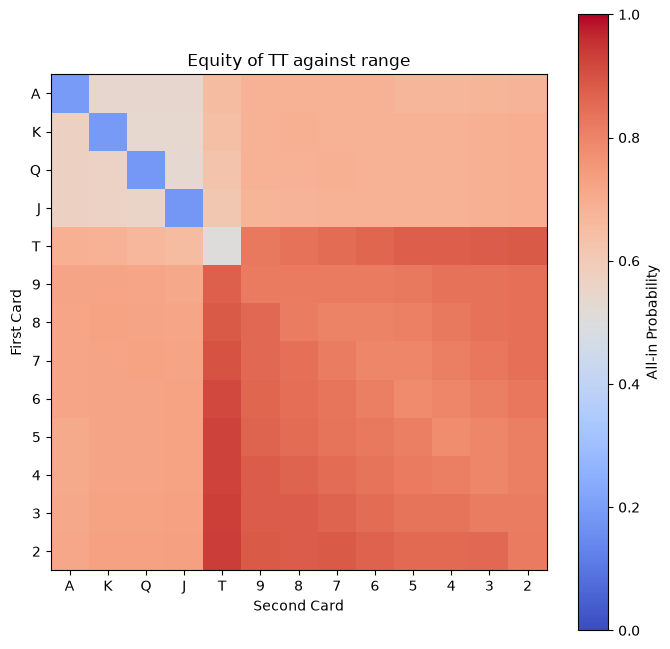

In [59]:
# Equity of a specific hand against all other hands
specific_hand: str = "TT"
specific_idx: int = hand_to_index(specific_hand)

specific_equity_matrix: np.ndarray = equity_matrix[specific_idx, :].reshape((13, 13))

frequency: list[int] = [ 6,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12,  6,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12,  6,  4,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12,  6,  4,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12,  6,  4,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12,  6,  4,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12,  6,  4,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12,  6,  4,  4,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12,  6,  4,  4,  4, 4, 
                        12, 12, 12, 12, 12, 12, 12, 12, 12,  6,  4,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12, 12,  6,  4, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12,  6, 4,
                        12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 6]
frequency_matrix: np.ndarray = np.array(frequency, dtype=np.int32)
    

print(f"=== Equity of {specific_hand} against all other hands ===")
print(specific_equity_matrix)
    
import matplotlib.pyplot as plt
# heatmap of the 13x13 equity matrix. Red for 0.0 equity, and Green for 1.0 equity
plt.figure(figsize=(8, 8))
plt.imshow(specific_equity_matrix, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(label='All-in Probability')
plt.xticks(ticks=np.arange(13), labels=['A','K','Q','J','T','9','8','7','6','5','4','3','2'])
plt.yticks(ticks=np.arange(13), labels=['A','K','Q','J','T','9','8','7','6','5','4','3','2'])
plt.xlabel('Second Card')
plt.ylabel('First Card')
plt.title(f'Equity of {specific_hand} against range')
plt.show()